# Laboratorio 4 — Cuaderno 13: mapas predictivos de probabilidad

**Ejercicio 9 de la Parte 2.**

Hasta aquí el modelo se ha resumido en tablas de métricas. Un número como "F2 = 0.9438" no
le dice nada a quien tiene que decidir dónde mandar una lancha a tomar muestras. Este
cuaderno devuelve las predicciones al espacio: reconstruye la rejilla del raster, dibuja
un mapa de probabilidad para cada lago y localiza **dónde** se equivoca el modelo.

Esa última parte es la que más valor operativo tiene. Un error repartido al azar por el
lago es ruido tolerable; un error concentrado siempre en la misma bahía es un punto ciego,
y hay que saber dónde está antes de confiar en el sistema.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap
from sklearn.model_selection import StratifiedGroupKFold

from src import config, datos as dts, graficos, ml
from src import indices as ix

SEMILLA = 42

datos = pd.read_parquet(config.DERIVADO / "dataset_ml.parquet")
datos[ml.RESPUESTA] = ml.variable_respuesta(datos)
datos = ml.caracteristicas(datos)
datos["bloque"] = ml.asignar_bloques(datos, 1000.0)

X, y = datos[ml.PREDICTORAS], datos[ml.RESPUESTA]
print(f"{len(datos):,} observaciones a predecir")

3,759,121 observaciones a predecir


## 9.1 Probabilidad de alta presencia para cada observación

Hay una trampa que evitar. Si se usara el modelo del cuaderno 9 para pintar el mapa
completo, la mayoría de los píxeles del mapa habrían estado en su conjunto de
entrenamiento, y el mapa mostraría lo bien que el modelo recuerda, no lo bien que predice.

Para que el mapa sea honesto en toda su extensión se calculan **predicciones fuera de
muestra por bloques espaciales**: se reparten los bloques de 1 km en cinco particiones y
cada píxel recibe su probabilidad de un modelo que nunca vio ningún píxel de su bloque. Es
la misma estrategia del cuaderno 10, usada aquí para producir un mapa en lugar de una
métrica.

In [2]:
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
probabilidad = np.full(len(datos), np.nan)

for k, (i_ent, i_pru) in enumerate(sgkf.split(X, y, groups=datos["bloque"])):
    X_fit, y_fit = ml.submuestra_entrenamiento(
        X.iloc[i_ent], y.iloc[i_ent], razon=1.0, semilla=SEMILLA + k
    )
    modelo = ml.construir_modelo("XGBoost", SEMILLA)
    modelo.fit(X_fit, y_fit)
    probabilidad[i_pru] = modelo.predict_proba(X.iloc[i_pru])[:, 1]
    print(f"  partición {k}: {len(i_pru):>9,} píxeles predichos")

datos["prob_cruda"] = probabilidad
print(f"\nSin predecir: {int(np.isnan(probabilidad).sum())}")

  partición 0:   751,721 píxeles predichos


  partición 1:   751,757 píxeles predichos


  partición 2:   752,071 píxeles predichos


  partición 3:   751,661 píxeles predichos


  partición 4:   751,911 píxeles predichos

Sin predecir: 0


### Corrección de la probabilidad a la prevalencia real

Los modelos se entrenaron sobre muestras al 50 % de positivos, así que sus probabilidades
corresponden a ese mundo y no al lago. Es el mismo desajuste que en el cuaderno 9 se
resolvió moviendo el umbral a 0.99. Para un mapa eso no basta: el enunciado pide una escala
que distinga probabilidad muy baja, baja, alta y muy alta, y una escala en la que todo lo
interesante ocurre entre 0.98 y 1.00 no distingue nada.

La solución estándar para muestreo por casos y controles es corregir la probabilidad por la
razón de prevalencias:

$$p_{\text{real}} = \frac{p\,\dfrac{\pi_0}{\pi_1}}{p\,\dfrac{\pi_0}{\pi_1} + (1-p)\,\dfrac{1-\pi_0}{1-\pi_1}}$$

donde $\pi_1 = 0.5$ es la prevalencia con la que se entrenó y $\pi_0 = 0.0118$ la real. Tras
la corrección, las probabilidades vuelven a ser interpretables como lo que dicen ser, y los
cortes de la escala pasan a tener significado.

In [3]:
PI_ENTRENAMIENTO = 0.5
PI_REAL = float(y.mean())

def corregir_prior(p, pi_ent=PI_ENTRENAMIENTO, pi_real=PI_REAL):
    razon = pi_real / pi_ent
    razon_neg = (1 - pi_real) / (1 - pi_ent)
    return (p * razon) / (p * razon + (1 - p) * razon_neg)

datos["prob"] = corregir_prior(datos["prob_cruda"].values)

print(f"Prevalencia de entrenamiento: {PI_ENTRENAMIENTO:.4f}")
print(f"Prevalencia real:             {PI_REAL:.4f}\n")

comparacion = pd.DataFrame({
    "cruda": datos["prob_cruda"].describe(percentiles=[0.5, 0.9, 0.99]),
    "corregida": datos["prob"].describe(percentiles=[0.5, 0.9, 0.99]),
}).round(4)
print(comparacion.to_string())

print(f"\nProbabilidad media corregida: {datos['prob'].mean():.4f} "
      f"(prevalencia real: {PI_REAL:.4f})")

Prevalencia de entrenamiento: 0.5000
Prevalencia real:             0.0118

              cruda     corregida
count  3.759121e+06  3.759121e+06
mean   1.820000e-02  1.360000e-02
std    1.287000e-01  1.116000e-01
min    0.000000e+00  0.000000e+00
50%    0.000000e+00  0.000000e+00
90%    0.000000e+00  0.000000e+00
99%    9.998000e-01  9.810000e-01
max    1.000000e+00  1.000000e+00

Probabilidad media corregida: 0.0136 (prevalencia real: 0.0118)


## 9.4 Escala de la probabilidad

Con las probabilidades ya corregidas se definen las cuatro categorías que pide el
enunciado. Los cortes no son arbitrarios: se anclan a la prevalencia real del 1.18 %, que
es la probabilidad que tendría un píxel del que no se sabe nada.

| Categoría | Probabilidad corregida | Lectura operativa |
|---|---|---|
| Muy baja | < 0.01 | Por debajo de la prevalencia base; nada que revisar |
| Baja | 0.01 – 0.10 | Sospecha leve; entra en el seguimiento rutinario |
| Alta | 0.10 – 0.50 | Zona candidata a muestreo |
| Muy alta | > 0.50 | Más probable que no; muestreo prioritario |

In [4]:
CORTES = [0.0, 0.01, 0.10, 0.50, 1.0]
ETIQUETAS = ["Muy baja", "Baja", "Alta", "Muy alta"]
COLORES = ["#2c7bb6", "#abd9e9", "#fdae61", "#d7191c"]

CMAP = ListedColormap(COLORES)
CMAP.set_bad((0, 0, 0, 0))
NORMA = BoundaryNorm(CORTES, CMAP.N)

datos["categoria"] = pd.cut(datos["prob"], bins=CORTES, labels=ETIQUETAS, include_lowest=True)

reparto = pd.crosstab(datos["categoria"], datos[ml.RESPUESTA], normalize="index")
conteo = datos["categoria"].value_counts().reindex(ETIQUETAS)

print(f"{'categoría':<12}{'píxeles':>12}{'% del total':>13}{'% que son positivos reales':>29}")
print("-" * 66)
for etiqueta in ETIQUETAS:
    pos = 100 * reparto.loc[etiqueta, 1] if 1 in reparto.columns else 0.0
    print(f"{etiqueta:<12}{conteo[etiqueta]:>12,}{100*conteo[etiqueta]/len(datos):>12.2f} %"
          f"{pos:>28.2f} %")

categoría        píxeles  % del total   % que son positivos reales
------------------------------------------------------------------
Muy baja       3,691,057       98.19 %                        0.00 %
Baja               9,646        0.26 %                        3.86 %
Alta               7,640        0.20 %                       13.98 %
Muy alta          50,778        1.35 %                       84.15 %


La última columna es la comprobación de que la escala significa algo: la proporción de
píxeles que de verdad superan el umbral de la OMS crece de forma monótona al subir de
categoría. Una escala de probabilidad en la que esto no ocurriera sería decorativa.

## 9.2 y 9.3 Mapas predictivos por lago

Se reconstruye la rejilla del raster con las columnas `fila` y `columna` que el conjunto de
datos guarda para este fin. Para cada lago se muestran dos fechas: la más limpia y la más
afectada de la serie.

In [5]:
def rejilla(lago, fecha, columna):
    # Coloca la columna pedida de vuelta en la rejilla del raster, dejando NaN
    # donde no habia agua valida.
    sub = datos[(datos["lago"] == lago) & (datos["fecha"] == pd.Timestamp(fecha))]
    capas, _ = dts.indices_escena(lago, fecha)
    salida = np.full(capas["chl_agua"].shape, np.nan, dtype=np.float32)
    salida[sub["fila"].values, sub["columna"].values] = sub[columna].values
    return salida


fechas_clave = {}
for lago in ["Atitlan", "Amatitlan"]:
    sub = datos[datos["lago"] == lago].groupby("fecha")[ml.RESPUESTA].mean()
    fechas_clave[lago] = {
        "limpia": sub.idxmin().strftime("%Y-%m-%d"),
        "afectada": sub.idxmax().strftime("%Y-%m-%d"),
    }
    print(f"{lago:<11} más limpia: {fechas_clave[lago]['limpia']} "
          f"({100*sub.min():.3f} % positivos)   "
          f"más afectada: {fechas_clave[lago]['afectada']} ({100*sub.max():.2f} %)")

Atitlan     más limpia: 2026-04-28 (0.002 % positivos)   más afectada: 2026-07-22 (0.14 %)
Amatitlan   más limpia: 2026-02-02 (0.014 % positivos)   más afectada: 2026-06-19 (53.39 %)


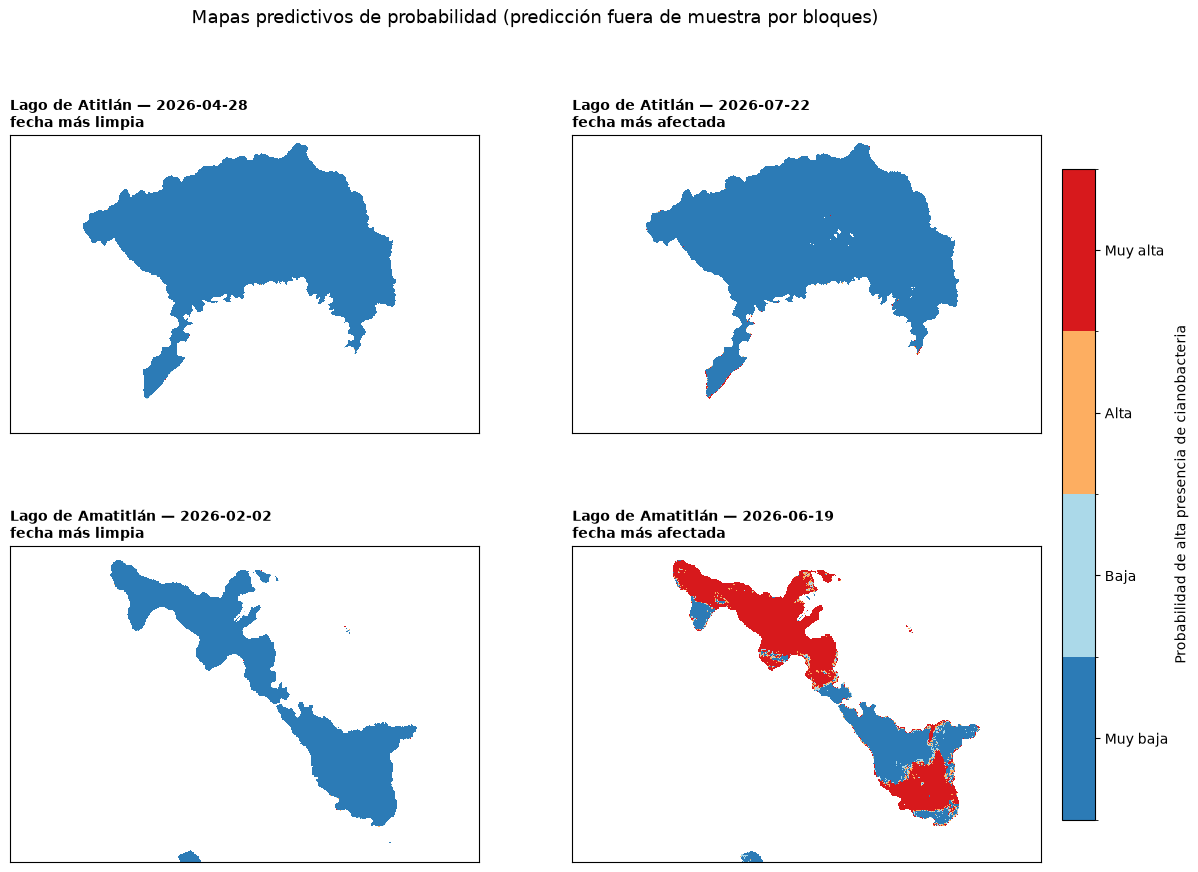

In [6]:
fig, ejes = plt.subplots(2, 2, figsize=(14, 10))

for i, lago in enumerate(["Atitlan", "Amatitlan"]):
    for j, momento in enumerate(["limpia", "afectada"]):
        fecha = fechas_clave[lago][momento]
        eje = ejes[i, j]
        eje.imshow(rejilla(lago, fecha, "prob"), cmap=CMAP, norm=NORMA,
                   interpolation="nearest")
        eje.set_title(f"{config.NOMBRE_LARGO[lago]} — {fecha}\nfecha más {momento}",
                      loc="left", fontsize=10, fontweight="bold")
        eje.set_xticks([]); eje.set_yticks([])

barra = fig.colorbar(plt.cm.ScalarMappable(norm=NORMA, cmap=CMAP), ax=ejes,
                     fraction=0.03, pad=0.02, spacing="uniform", ticks=[0.005, 0.055, 0.3, 0.75])
barra.ax.set_yticklabels(ETIQUETAS)
barra.set_label("Probabilidad de alta presencia de cianobacteria")

fig.suptitle("Mapas predictivos de probabilidad (predicción fuera de muestra por bloques)",
             y=0.98, fontsize=13)
plt.show()

## 9.5 Comparación con los mapas de la Parte I

El mapa predictivo se pone al lado del mapa de clorofila del script CyanoLakes, que es la
referencia contra la que se construyó la etiqueta.

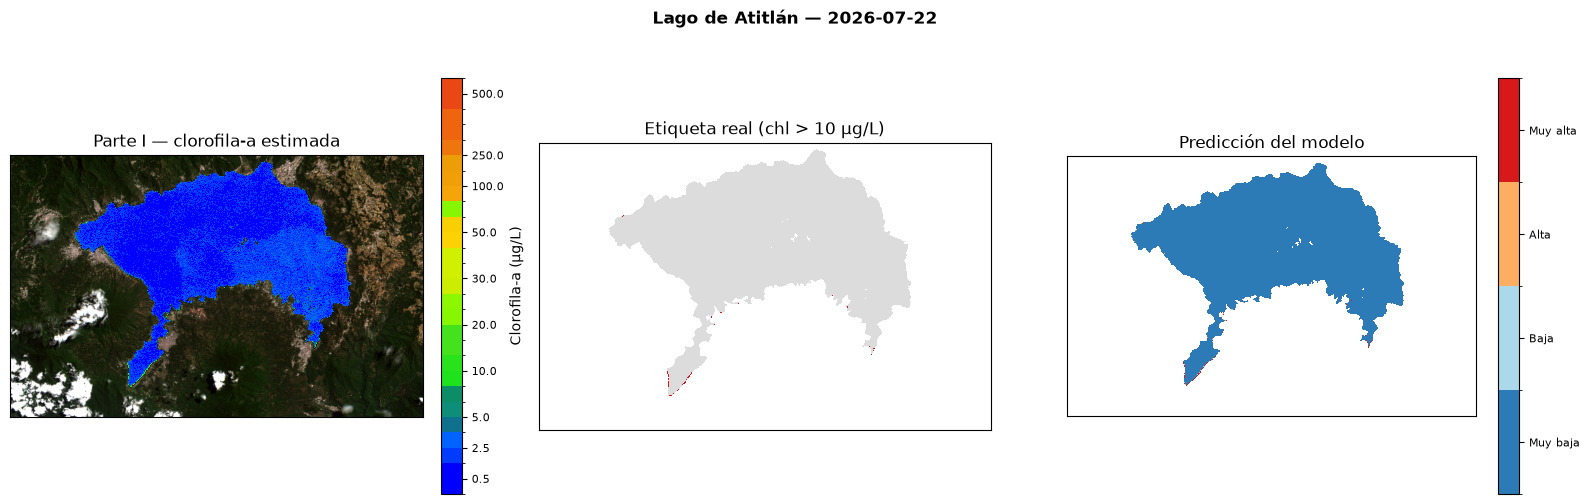

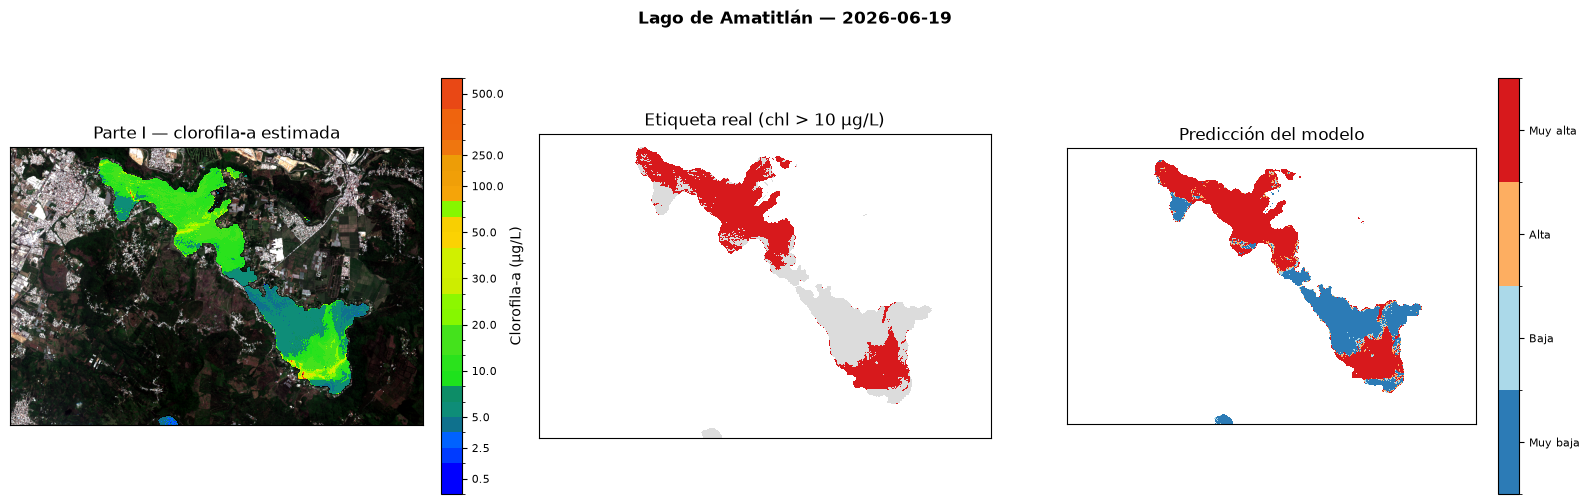

In [7]:
for lago in ["Atitlan", "Amatitlan"]:
    fecha = fechas_clave[lago]["afectada"]
    capas, _ = dts.indices_escena(lago, fecha)

    fig, ejes = plt.subplots(1, 3, figsize=(16, 5))

    graficos.dibujar_mapa_chl(ejes[0], capas, titulo="Parte I — clorofila-a estimada")
    graficos.barra_color_chl(fig, ejes[0])

    verdad = rejilla(lago, fecha, ml.RESPUESTA)
    ejes[1].imshow(np.ma.masked_invalid(verdad), cmap=ListedColormap(["#dcdcdc", "#d7191c"]),
                   interpolation="nearest")
    ejes[1].set_title(f"Etiqueta real (chl > {ml.UMBRAL_CHL:.0f} µg/L)")

    dibujo = ejes[2].imshow(rejilla(lago, fecha, "prob"), cmap=CMAP, norm=NORMA,
                            interpolation="nearest")
    ejes[2].set_title("Predicción del modelo")
    barra = fig.colorbar(dibujo, ax=ejes[2], fraction=0.046, spacing="uniform",
                         ticks=[0.005, 0.055, 0.3, 0.75])
    barra.ax.set_yticklabels(ETIQUETAS, fontsize=8)

    for eje in ejes:
        eje.set_xticks([]); eje.set_yticks([])

    fig.suptitle(f"{config.NOMBRE_LARGO[lago]} — {fecha}", y=1.02, fontsize=12,
                 fontweight="bold")
    fig.tight_layout()
    plt.show()

### Qué muestra la comparación

Los tres paneles se parecen mucho, y conviene decir con precisión qué significa eso.

El mapa predictivo reproduce la **geometría** de la floración: las manchas aparecen donde
el índice de la Parte I las pone, con la misma forma y aproximadamente la misma extensión.
En Amatitlán el 19 de junio de 2026 el modelo recupera la floración que cubre más de la
mitad del lago; en Atitlán reproduce el patrón de agua limpia con focos mínimos.

Lo importante es que el panel central y el derecho **no se construyeron con la misma
información**. La etiqueta sale de B04 y B05; la predicción no ha visto ninguna de las dos.
Que coincidan quiere decir que la firma de una floración es redundante a lo ancho del
espectro: está en el borde rojo de 705 nm que usa el NDCI, pero también en el de 783 nm, en
la razón azul/verde y en el contraste infrarrojo. Es un resultado real sobre la óptica del
agua.

Lo que **no** significa es que el modelo sea una fuente independiente de verdad. Si el
índice CyanoLakes se equivoca en una situación —agua muy somera donde se ve el fondo,
lirio acuático confundido con nata— el modelo aprendió a reproducir ese error, no a
corregirlo. Sin muestreo de campo no hay forma de distinguir una cosa de la otra.

## 9.6 Zonas correctamente detectadas, falsos positivos y falsos negativos

In [8]:
UMBRAL_MAPA = float(pd.Series(CORTES).iloc[3])  # 0.50 sobre la probabilidad corregida
datos["pred"] = (datos["prob"] >= UMBRAL_MAPA).astype(int)

def clase_error(fila_v, fila_p):
    return np.where(fila_v & fila_p, 3, np.where(fila_v & ~fila_p, 2,
                    np.where(~fila_v & fila_p, 1, 0)))

datos["tipo_error"] = clase_error(datos[ml.RESPUESTA].values.astype(bool),
                                  datos["pred"].values.astype(bool))

nombres_error = {0: "Verdadero negativo", 1: "Falso positivo",
                 2: "Falso negativo", 3: "Verdadero positivo"}
print("Reparto global de aciertos y errores (umbral 0.50 sobre probabilidad corregida)\n")
conteo_err = datos["tipo_error"].value_counts().sort_index()
for codigo, n in conteo_err.items():
    print(f"  {nombres_error[codigo]:<20}{n:>10,}   {100*n/len(datos):>6.2f} %")

print("\nPor lago:\n")
for lago, sub in datos.groupby("lago"):
    vp = int((sub["tipo_error"] == 3).sum()); fn = int((sub["tipo_error"] == 2).sum())
    fp = int((sub["tipo_error"] == 1).sum())
    recall = vp / (vp + fn) if vp + fn else np.nan
    precision = vp / (vp + fp) if vp + fp else np.nan
    print(f"  {lago:<11} VP {vp:>7,}  FP {fp:>7,}  FN {fn:>6,}   "
          f"recall {recall:.4f}   precisión {precision:.4f}")

Reparto global de aciertos y errores (umbral 0.50 sobre probabilidad corregida)

  Verdadero negativo   3,706,722    98.61 %
  Falso positivo           8,050     0.21 %
  Falso negativo           1,621     0.04 %
  Verdadero positivo      42,728     1.14 %

Por lago:



  Amatitlan   VP  41,587  FP   6,760  FN  1,438   recall 0.9666   precisión 0.8602
  Atitlan     VP   1,141  FP   1,290  FN    183   recall 0.8618   precisión 0.4694


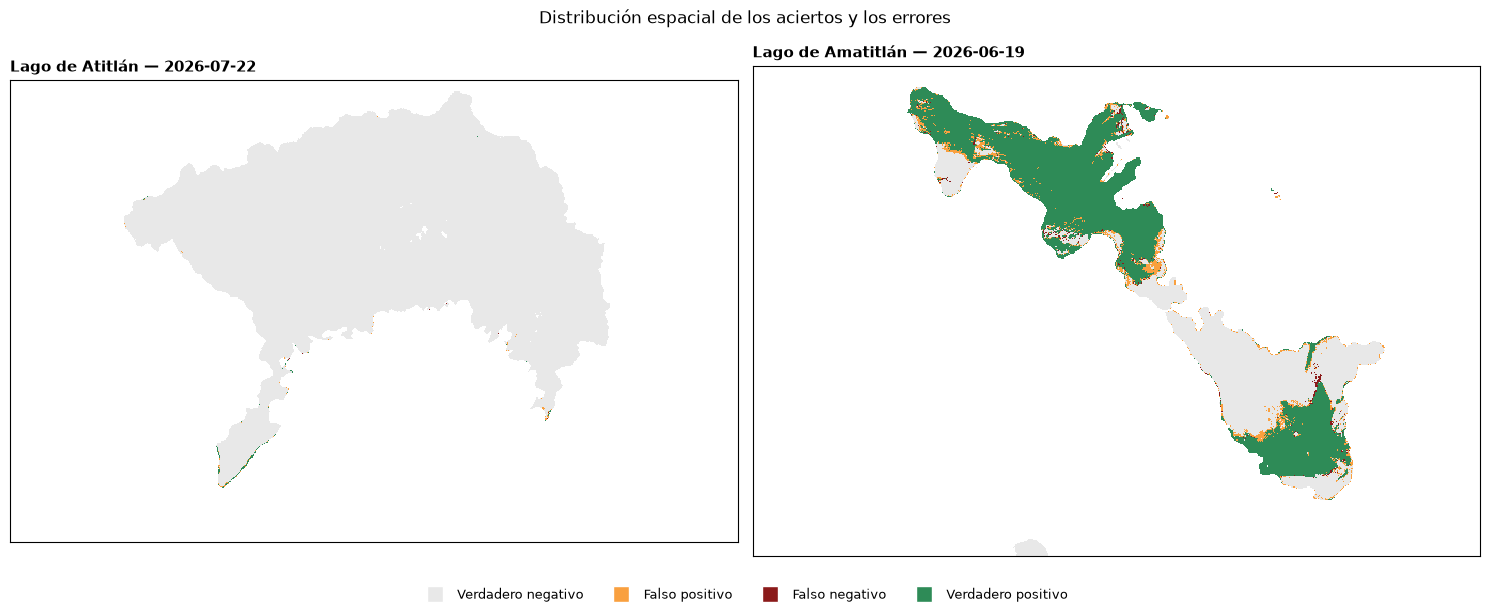

In [9]:
CMAP_ERROR = ListedColormap(["#e8e8e8", "#f9a03f", "#8b1a1a", "#2e8b57"])

fig, ejes = plt.subplots(1, 2, figsize=(15, 6))

for eje, lago in zip(ejes, ["Atitlan", "Amatitlan"]):
    fecha = fechas_clave[lago]["afectada"]
    eje.imshow(rejilla(lago, fecha, "tipo_error"), cmap=CMAP_ERROR, vmin=-0.5, vmax=3.5,
               interpolation="nearest")
    eje.set_title(f"{config.NOMBRE_LARGO[lago]} — {fecha}", loc="left",
                  fontsize=11, fontweight="bold")
    eje.set_xticks([]); eje.set_yticks([])

manijas = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=c, markersize=11, label=l)
           for c, l in zip(CMAP_ERROR.colors, [nombres_error[i] for i in range(4)])]
fig.legend(handles=manijas, loc="lower center", ncol=4, fontsize=9, frameon=False)
fig.suptitle("Distribución espacial de los aciertos y los errores", y=1.0, fontsize=12)
fig.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

## 9.7 ¿Hay regiones donde el modelo falla de forma sistemática?

Tres cortes distintos para responder: por cercanía al umbral, por distancia a la orilla y
por bloque espacial.

In [10]:
cerca = datos[(datos["chl"] > 0)].copy()
cerca["banda_chl"] = pd.cut(
    cerca["chl"],
    bins=[0, 2, 5, 8, 9.5, 10.5, 13, 20, 50, np.inf],
    labels=["0-2", "2-5", "5-8", "8-9.5", "9.5-10.5", "10.5-13", "13-20", "20-50", ">50"],
)

print("Tasa de error según lo cerca que esté la clorofila del umbral de 10 µg/L\n")
print(f"{'banda chl (µg/L)':<18}{'píxeles':>11}{'% error':>10}")
print("-" * 39)
for banda, sub in cerca.groupby("banda_chl", observed=True):
    err = 100 * (sub["pred"] != sub[ml.RESPUESTA]).mean()
    print(f"{str(banda):<18}{len(sub):>11,}{err:>9.2f} %")

Tasa de error según lo cerca que esté la clorofila del umbral de 10 µg/L

banda chl (µg/L)      píxeles   % error
---------------------------------------


0-2                 2,054,699     0.00 %
2-5                   973,296     0.02 %
5-8                   109,786     1.93 %
8-9.5                  12,669    29.65 %
9.5-10.5                5,825    44.43 %
10.5-13                11,698     7.16 %
13-20                  20,122     0.76 %
20-50                   9,223     0.21 %
>50                       607     0.49 %


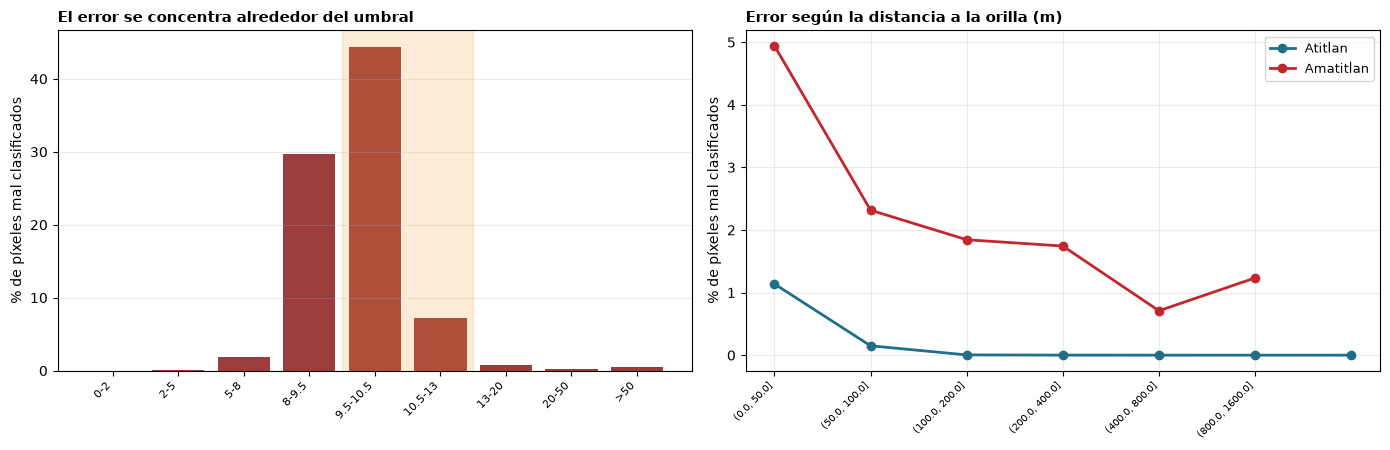

In [11]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 4.6))

tasa = cerca.groupby("banda_chl", observed=True).apply(
    lambda s: 100 * (s["pred"] != s[ml.RESPUESTA]).mean(), include_groups=False)
ejes[0].bar(range(len(tasa)), tasa.values, color="#8b1a1a", alpha=0.85)
ejes[0].set_xticks(range(len(tasa)), tasa.index.astype(str), rotation=45, ha="right", fontsize=8)
ejes[0].axvspan(3.5, 5.5, color="#f9a03f", alpha=0.2)
ejes[0].set_ylabel("% de píxeles mal clasificados")
ejes[0].set_title("El error se concentra alrededor del umbral", loc="left",
                  fontsize=11, fontweight="bold")
ejes[0].grid(alpha=0.25, axis="y")

datos["banda_orilla"] = pd.cut(datos["dist_orilla_m"],
                               bins=[0, 50, 100, 200, 400, 800, 1600, np.inf])
for lago, color in [("Atitlan", "#1f6f8b"), ("Amatitlan", "#c1272d")]:
    sub = datos[datos["lago"] == lago]
    tasa_o = sub.groupby("banda_orilla", observed=True).apply(
        lambda s: 100 * (s["pred"] != s[ml.RESPUESTA]).mean(), include_groups=False)
    ejes[1].plot(range(len(tasa_o)), tasa_o.values, "o-", color=color, label=lago, linewidth=2)
    ejes[1].set_xticks(range(len(tasa_o)),
                       [str(i) for i in tasa_o.index], rotation=45, ha="right", fontsize=7)
ejes[1].set_ylabel("% de píxeles mal clasificados")
ejes[1].set_title("Error según la distancia a la orilla (m)", loc="left",
                  fontsize=11, fontweight="bold")
ejes[1].legend(fontsize=9)
ejes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

In [12]:
print("Bloques espaciales con mayor tasa de falsos negativos")
print("(solo bloques con al menos 200 positivos reales)\n")

por_bloque = datos.groupby(["lago", "bloque"]).agg(
    positivos=(ml.RESPUESTA, "sum"),
    fn=("tipo_error", lambda s: int((s == 2).sum())),
    fp=("tipo_error", lambda s: int((s == 1).sum())),
    n=("prob", "size"),
    x=("x", "mean"), y=("y", "mean"),
).reset_index()
por_bloque["tasa_fn"] = por_bloque["fn"] / por_bloque["positivos"].replace(0, np.nan)

candidatos = por_bloque[por_bloque["positivos"] >= 200].sort_values("tasa_fn", ascending=False)
print(candidatos.head(10)[["lago", "bloque", "positivos", "fn", "tasa_fn"]].to_string(index=False))

print(f"\nBloques con positivos suficientes: {len(candidatos)}")
print(f"Tasa de falsos negativos — mediana {candidatos['tasa_fn'].median():.4f}, "
      f"máximo {candidatos['tasa_fn'].max():.4f}")

Bloques espaciales con mayor tasa de falsos negativos
(solo bloques con al menos 200 positivos reales)



     lago             bloque  positivos  fn  tasa_fn
Amatitlan Amatitlan_758_1601        786 127 0.161578
Amatitlan Amatitlan_765_1598        946 128 0.135307
Amatitlan Amatitlan_761_1599        328  34 0.103659
Amatitlan Amatitlan_765_1597        843  78 0.092527
Amatitlan Amatitlan_762_1599        488  39 0.079918
Amatitlan Amatitlan_757_1603        925  71 0.076757
Amatitlan Amatitlan_764_1598        702  53 0.075499
Amatitlan Amatitlan_763_1597        822  42 0.051095
Amatitlan Amatitlan_765_1596       2624 130 0.049543
Amatitlan Amatitlan_761_1602       2044  99 0.048434

Bloques con positivos suficientes: 31
Tasa de falsos negativos — mediana 0.0306, máximo 0.1616


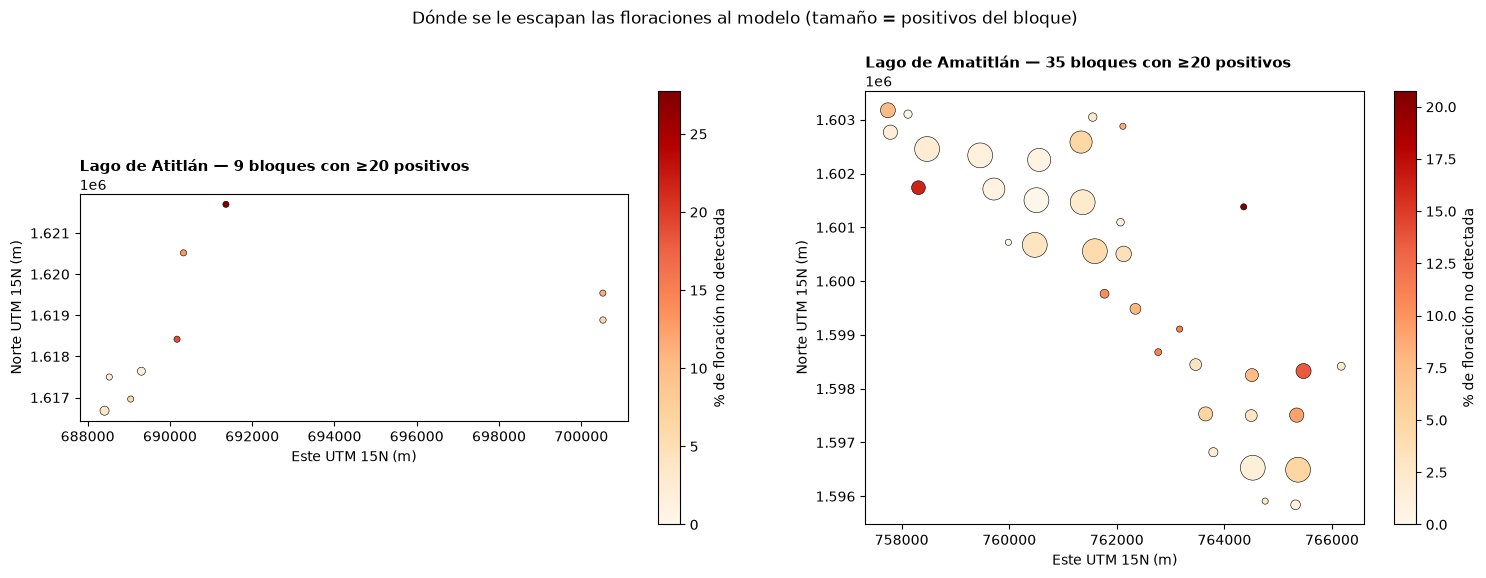

In [13]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5.6))

for eje, lago in zip(ejes, ["Atitlan", "Amatitlan"]):
    sub = por_bloque[(por_bloque["lago"] == lago) & (por_bloque["positivos"] >= 20)]
    if len(sub) == 0:
        eje.set_visible(False)
        continue
    dibujo = eje.scatter(sub["x"], sub["y"], c=100 * sub["tasa_fn"],
                         s=np.clip(sub["positivos"] / 8, 20, 320),
                         cmap="OrRd", edgecolor="black", linewidth=0.4, vmin=0)
    fig.colorbar(dibujo, ax=eje, label="% de floración no detectada", fraction=0.046)
    eje.set_title(f"{config.NOMBRE_LARGO[lago]} — {len(sub)} bloques con ≥20 positivos",
                  loc="left", fontsize=11, fontweight="bold")
    eje.set_xlabel("Este UTM 15N (m)"); eje.set_ylabel("Norte UTM 15N (m)")
    eje.set_aspect("equal")

fig.suptitle("Dónde se le escapan las floraciones al modelo (tamaño = positivos del bloque)",
             y=1.01)
fig.tight_layout()
plt.show()

### Lectura de los errores

Con el umbral en 0.50 sobre la probabilidad corregida, el reparto global es de 42,728
verdaderos positivos, 8,050 falsos positivos y 1,621 falsos negativos. Pero el promedio
esconde que los dos lagos están en situaciones muy distintas:

| Lago | Recall | Precisión | Lectura |
|---|---|---|---|
| Amatitlán | 0.9666 | 0.8602 | Detecta casi todo, con una falsa alarma por cada seis aciertos |
| Atitlán | 0.8618 | **0.4694** | Detecta menos y **más de la mitad de sus avisos son falsos** |

En Atitlán el modelo produce 1,290 falsos positivos frente a 1,141 verdaderos. Es
coherente con lo que encontró el cuaderno 11: con 1,324 positivos en 3.36 millones de
píxeles, no hay material suficiente para caracterizar el fenómeno en ese lago, y el modelo
resuelve la duda marcando de más. Para el uso previsto —dirigir muestreos— es el error
tolerable de los dos, pero significa que en Atitlán aproximadamente una de cada dos
salidas de campo sería en vano.

En los mapas de error se ve además que los falsos positivos no se reparten al azar: forman
un **halo alrededor de las manchas verdaderas**. Es el borde de la floración, donde la
concentración pasa por el umbral de 10 µg/L y la clasificación se decide por márgenes
mínimos. Eso lleva directamente al inciso siguiente.

### 9.7 La respuesta: el problema no es dónde, es cuánto

La tabla de error por banda de clorofila es el resultado más nítido del cuaderno:

| Clorofila real (µg/L) | Píxeles | % mal clasificados |
|---|---|---|
| 0 – 2 | 2,054,699 | 0.00 % |
| 2 – 5 | 973,296 | 0.02 % |
| 5 – 8 | 109,786 | 1.93 % |
| 8 – 9.5 | 12,669 | 29.65 % |
| **9.5 – 10.5** | **5,825** | **44.43 %** |
| 10.5 – 13 | 11,698 | 7.16 % |
| 13 – 20 | 20,122 | 0.76 % |
| 20 – 50 | 9,223 | 0.21 % |
| > 50 | 607 | 0.49 % |

El error es **prácticamente cero en los dos extremos y casi una moneda al aire en la banda
que rodea al umbral**. En el intervalo de 9.5 a 10.5 µg/L el modelo acierta el 55.6 % de
las veces, apenas mejor que el azar. Dos bandas más allá, en cualquiera de las dos
direcciones, no falla nunca.

Esto no es un defecto del modelo: **es una consecuencia inevitable de haber binarizado una
variable continua.** Un píxel con 9.9 µg/L y otro con 10.1 tienen espectros
indistinguibles —la diferencia está muy por debajo del ruido radiométrico del sensor— pero
la etiqueta los separa en clases opuestas. Ningún clasificador puede resolver esa
distinción, porque la información física para hacerlo no existe en la imagen.

La consecuencia práctica es tranquilizadora más que preocupante. Las floraciones que
importan desde el punto de vista sanitario —las que se acercan al nivel de alerta de
50 µg/L— caen en las bandas donde el modelo no se equivoca casi nunca. El modelo falla
justo donde la propia distinción entre "hay" y "no hay" es más discutible.

### ¿Y regiones sistemáticamente difíciles?

En el sentido geográfico, **no de forma marcada**. Entre los 31 bloques con al menos 200
positivos reales, la tasa mediana de floración no detectada es del 3.06 % y el peor bloque
llega al 16.16 %. Es una variación real pero moderada, y los bloques peores no se agrupan
en una zona concreta: aparecen repartidos a lo largo de Amatitlán, con coordenadas este
entre 757 y 765 km y norte entre 1,596 y 1,603 km. No hay una bahía ciega.

La dependencia con la distancia a la orilla tampoco muestra un patrón fuerte, algo
esperable después de lo que encontró el cuaderno 12: la permutación mostró que
`dist_orilla_m` casi no interviene en las predicciones.

**La conclusión del inciso 9.7 es entonces que la dificultad del modelo no está organizada
en el espacio sino en el valor.** Donde falla es en el borde de las manchas —el contorno
donde la concentración cruza el umbral— y ese borde se mueve con la floración en lugar de
quedarse fijo en una parte del lago. Un gestor que use estos mapas no necesita desconfiar
de una región concreta; necesita saber que el **contorno** de cada mancha tiene una
incertidumbre de unos pocos píxeles, mientras que el **núcleo** es fiable.

In [14]:
datos[["lago", "fecha", "fila", "columna", "x", "y", "prob", "pred",
       ml.RESPUESTA, "tipo_error"]].to_parquet(
    config.DERIVADO / "predicciones_mapa.parquet", index=False)
print("Predicciones guardadas para el informe.")

Predicciones guardadas para el informe.


---

**Siguiente:** `14_Conclusiones.ipynb` — análisis, limitaciones y conclusiones
(ejercicio 10).